# Libraries and Dataset Load

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Load the dataset
df = pd.read_csv('../data/healthcare-dataset-stroke-data.csv')

# Datset general information

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [3]:
features_only = df.select_dtypes(include=['float64', 'int64']).drop(columns=['id', 'stroke'])
features_only.describe()

,age,hypertension,heart_disease,avg_glucose_level,bmi
count,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000
mean,43.226614,0.097456,0.054012,106.147677,28.893237
std,22.612647,0.296607,0.226063,45.283560,7.854067
min,0.080000,0.000000,0.000000,55.120000,10.300000
25%,25.000000,0.000000,0.000000,77.245000,23.500000
50%,45.000000,0.000000,0.000000,91.885000,28.100000
75%,61.000000,0.000000,0.000000,114.090000,33.100000
max,82.000000,1.000000,1.000000,271.740000,97.600000


In [11]:
# Returns the total number of redundant rows
total_duplicates = df.duplicated().sum()
print(f"Total duplicate rows: {total_duplicates}")

Total duplicate rows: 0


In [12]:
# Returns the count of rows that have at least one NaN
rows_with_missing_count = df.isnull().any(axis=1).sum()
print(f"Rows with missing data: {rows_with_missing_count}")

Rows with missing data: 201


# Target Distrobution

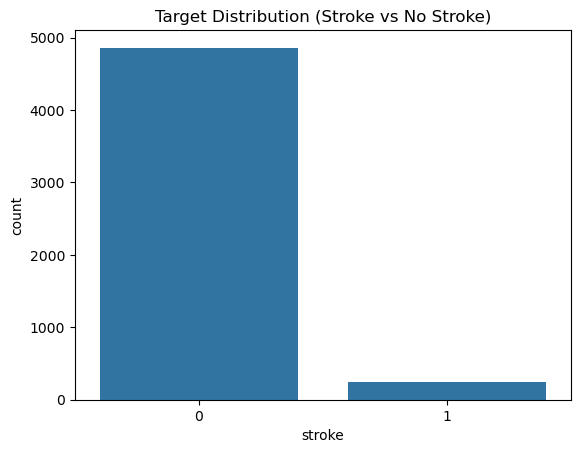

stroke
0    0.951272
1    0.048728
Name: proportion, dtype: float64

In [4]:
# See how rare stroke cases are in your data
sns.countplot(x='stroke', data=df)
plt.title('Target Distribution (Stroke vs No Stroke)')
plt.show()

df['stroke'].value_counts(normalize=True)

### From the graph we can see that there is a big gap in distrobution of records for the stroke column in the dataset.

# Feature Correlation

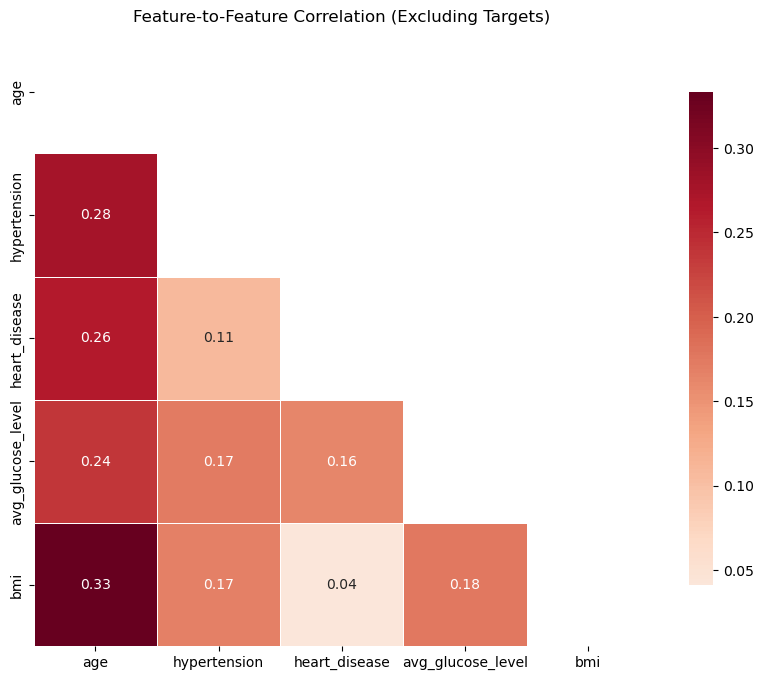

In [5]:

corr = features_only.corr()

# 2. Generate a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# 3. Plot
plt.figure(figsize=(10, 8))
sns.heatmap(corr, 
            mask=mask, 
            annot=True, 
            fmt=".2f", 
            cmap='RdBu_r', 
            center=0,
            square=True, 
            linewidths=.5, 
            cbar_kws={"shrink": .8})

plt.title('Feature-to-Feature Correlation (Excluding Targets)')
plt.show()

### Biggest correlation between Age and BMI. Age seemingly the highest weighted in general.

# Outlier Detection

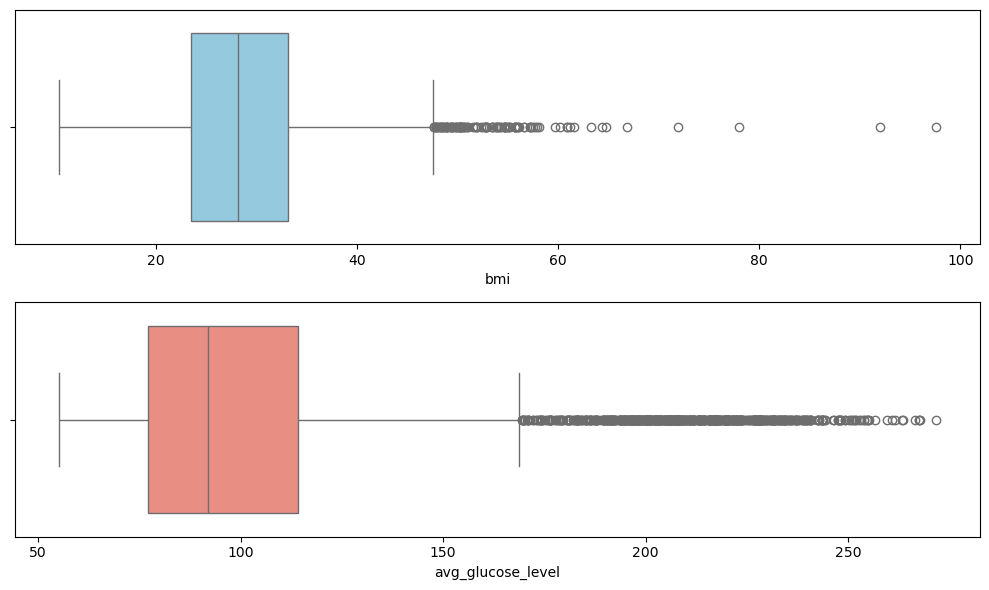

In [6]:
# Create horizontal boxplots to avoid the "stretched" vertical look
fig, ax = plt.subplots(2, 1, figsize=(10, 6)) # 2 rows, 1 column for better vertical stacking

# Use x= instead of y= for horizontal orientation
sns.boxplot(x='bmi', data=df, ax=ax[0], color='skyblue')
sns.boxplot(x='avg_glucose_level', data=df, ax=ax[1], color='salmon')

plt.tight_layout() # Prevents label overlapping
plt.show()

### Both BMI and Average Glucose Level have many outliers. These have to be adjusted for the training set ensure reliability.